# Project 2: Acquiring and Evaluating Data 

- Author: Kim Hummel
- Date: 2026-07
- Dataset: Seaborn Titanic
- Target: Survived 

In this project we will follow the outline provided by Denise Case to clean data and engineer features before practicing using a train/test split and a stratified split on the Titanic data set from seaborn. This data set has numerical and categorical features. 

## Section 1. Project Setup and Imports

All imports and configuration appear once, at the top of the notebook.
Bring in the libraries, configure a logger,
set a few constants you may customize, and
confirm the packages are installed by logging their versions.



In [1]:
# === Section 1a. DECLARE IMPORTS (BRING IN FREE CODE) ===

from importlib.metadata import version  # to verify
import logging  # for type hinting
import platform  # to verify
from typing import Final  # for type hinting

from datafun_toolkit.logger import get_logger, log_header
import matplotlib.pyplot as plt
import pandas as pd
import pandas.plotting
from pandas.plotting import scatter_matrix
import seaborn as sns
from sklearn.model_selection import StratifiedShuffleSplit, train_test_split

# === Section 1b. CONFIGURE LOGGER ONCE PER NOTEBOOK ===

LOG: logging.Logger = get_logger("M01", level="DEBUG")
log_header(LOG, "M01")

# === Section 1c. USE THE LOGGER TO VERIFY IMPORTS ===

# If any do NOT return a version number, then that package is not installed correctly.
# Check your pyproject.toml and re-run environment setup commands.

LOG.info("Confirming installation:")
LOG.info(f"  python:       {platform.python_version()}")
LOG.info(f"  pandas:       {version('pandas')}")
LOG.info(f"  numpy:        {version('numpy')}")
LOG.info(f"  scikit-learn: {version('scikit-learn')}")
LOG.info(f"  seaborn:      {version('seaborn')}")
LOG.info(f"  matplotlib:   {version('matplotlib')}")

# Load Titanic dataset
titanic = sns.load_dataset('titanic')
LOG.info("Loaded dataset titanic")

# === Section 1d. SET PANDAS DISPLAY CONFIGURATION (helps in notebooks) ===

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

2026-07-16 12:02:21 | INFO | M01 | === RUN START ===
2026-07-16 12:02:21 | INFO | M01 | project=M01
2026-07-16 12:02:21 | INFO | M01 | repo_dir=ml-02-features
2026-07-16 12:02:21 | INFO | M01 | python=3.14.3
2026-07-16 12:02:21 | INFO | M01 | os=Windows 11
2026-07-16 12:02:21 | INFO | M01 | shell=powershell
2026-07-16 12:02:21 | INFO | M01 | cwd=notebooks
2026-07-16 12:02:21 | INFO | M01 | github_actions=False
2026-07-16 12:02:21 | INFO | M01 | Confirming installation:
2026-07-16 12:02:21 | INFO | M01 |   python:       3.14.3
2026-07-16 12:02:21 | INFO | M01 |   pandas:       3.0.3
2026-07-16 12:02:21 | INFO | M01 |   numpy:        2.5.1
2026-07-16 12:02:21 | INFO | M01 |   scikit-learn: 1.9.0
2026-07-16 12:02:21 | INFO | M01 |   seaborn:      0.13.2
2026-07-16 12:02:21 | INFO | M01 |   matplotlib:   3.11.0
2026-07-16 12:02:21 | INFO | M01 | Loaded dataset titanic


## Section 1. Load the Data


In [2]:
DATASET_NAME: Final[str] = "titanic"

LOG.info(f"Loading dataset: {DATASET_NAME}")
LOG.info(
    f"Loaded: {titanic.shape[0]} rows (instances), {titanic.shape[1]} columns (features)"
)
titanic.info()

2026-07-16 12:02:21 | INFO | M01 | Loading dataset: titanic
2026-07-16 12:02:21 | INFO | M01 | Loaded: 891 rows (instances), 15 columns (features)


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


## Section 1. Inspect the Data

Numerical vs Categorical Columns.

Missing Values.

Print first 5 rows.

Describe the data. 

Correlations between features. 


In [3]:
# === Section 3. Inspect and Characterize the Data in ML Terms ===

row_count, col_count = titanic.shape

LOG.info(f"Instances (rows): {row_count}")  # or titanic.shape[0]
LOG.info(
    f"Features (columns): {col_count}"
)  # or titanic.shape[1] or len(titanic.columns)

numeric_cols_list: list[str] = titanic.select_dtypes(include="number").columns.tolist()
category_cols_list: list[str] = titanic.select_dtypes(exclude="number").columns.tolist()

LOG.info(f"Numeric columns (regression target / numeric feature): {numeric_cols_list}")
LOG.info(
    f"Categorical columns (classification target / category): {category_cols_list}"
)

missing: pd.Series = titanic.isna().sum()
LOG.info(f"Missing values by column:\n{missing}")

missing_total: int = int(missing.sum())
LOG.info(f"Missing values across all columns: {missing_total}")

LOG.debug(f"{titanic.head(5)}")

2026-07-16 12:02:22 | INFO | M01 | Instances (rows): 891
2026-07-16 12:02:22 | INFO | M01 | Features (columns): 15
2026-07-16 12:02:22 | INFO | M01 | Numeric columns (regression target / numeric feature): ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
2026-07-16 12:02:22 | INFO | M01 | Categorical columns (classification target / category): ['sex', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']
2026-07-16 12:02:22 | INFO | M01 | Missing values by column:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64
2026-07-16 12:02:22 | INFO | M01 | Missing values across all columns: 869
2026-07-16 12:02:22 | DEBUG | M01 |    survived  pclass     sex   age  sibsp  parch     fare embarked  class    who  adult_m

In [4]:
titanic.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
print(titanic.corr(numeric_only=True))

            survived    pclass       age     sibsp     parch      fare  adult_male     alone
survived    1.000000 -0.338481 -0.077221 -0.035322  0.081629  0.257307   -0.557080 -0.203367
pclass     -0.338481  1.000000 -0.369226  0.083081  0.018443 -0.549500    0.094035  0.135207
age        -0.077221 -0.369226  1.000000 -0.308247 -0.189119  0.096067    0.280328  0.198270
sibsp      -0.035322  0.083081 -0.308247  1.000000  0.414838  0.159651   -0.253586 -0.584471
parch       0.081629  0.018443 -0.189119  0.414838  1.000000  0.216225   -0.349943 -0.583398
fare        0.257307 -0.549500  0.096067  0.159651  0.216225  1.000000   -0.182024 -0.271832
adult_male -0.557080  0.094035  0.280328 -0.253586 -0.349943 -0.182024    1.000000  0.404744
alone      -0.203367  0.135207  0.198270 -0.584471 -0.583398 -0.271832    0.404744  1.000000


# Reflection #1
1) How many data instances are there? - There are 891 data instances, or rows. 
2) How many features are there? - There are 15 features, or columns. 
3) What are the names? - the names of the columns are " survived, pclass, sex, age, sibsp, parch, fare, embarked, class, who, adult_male, deck, embark_town, alive, alone
4) Are there any missing values? - Yes, there are missing values in the age, deck, and embark_town features for a total of 869 missing data points. 
5) Are there any non-numeric features? - Yes, there are 9 non-numeric features: sex, embarked, class, who, adult_male, deck, embark_town, alive, alone 

6) Are the data instances sorted on any of the attributes? - No, there does not seem to be any sorting. 
7) What are the units of age? - Years. 
8) What are the minimum, median and max age? - The minimum age is 0.42 years, the median age is 28 years, and the maximum age in 80 years. 
9) What two different features have the highest correlation? - The strongest correlation is a negative correlation between the features alone and sibsp with alone and parch right behind it by 0.001. This makes sense because if you are alone you are no expected to be traveling with a sibling or spouse (sibsp feature) or a parent or a child (parch feature). Because these features are all inter-related I would probably focus on the pair with the third largest correlation; adult male and survived with a correlation of -.0557. 
10) Are there any categorical features that might be useful for prediction? The categorical feature "deck" might be useful for the prediction if they survived or not as which deck they were on might have played a part into whether or not they were able to get on life boats or off of the ship. 

## Section 2. Data Exploration and Preparation 

Create a scatter plot of age vs fare, colored by gender:

Create a histogram of age:

Create a count plot for class and survival:


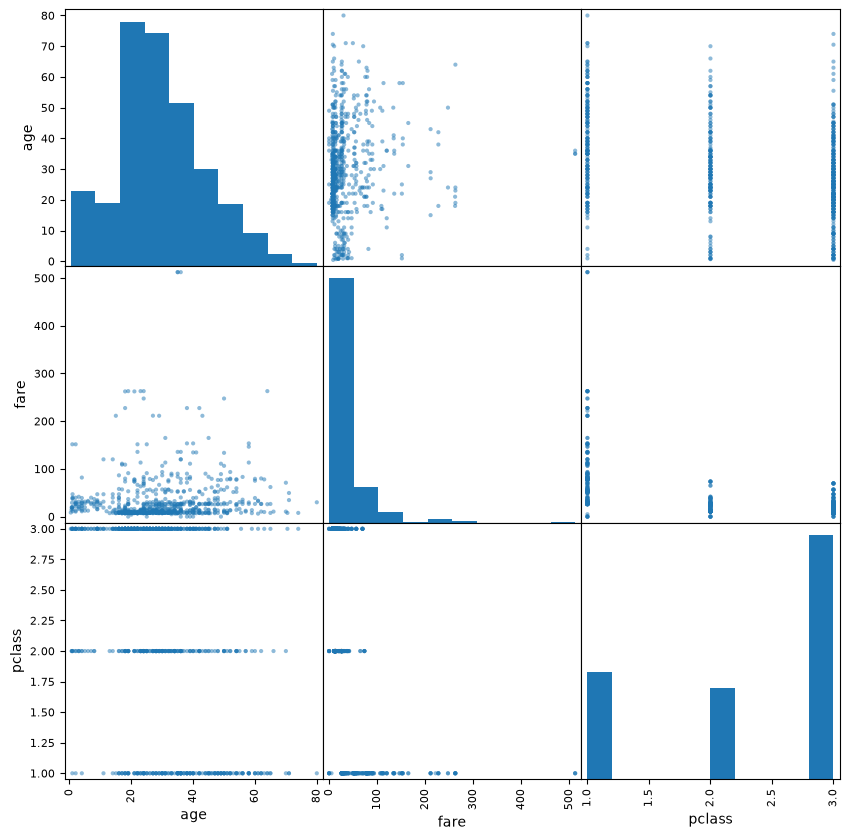

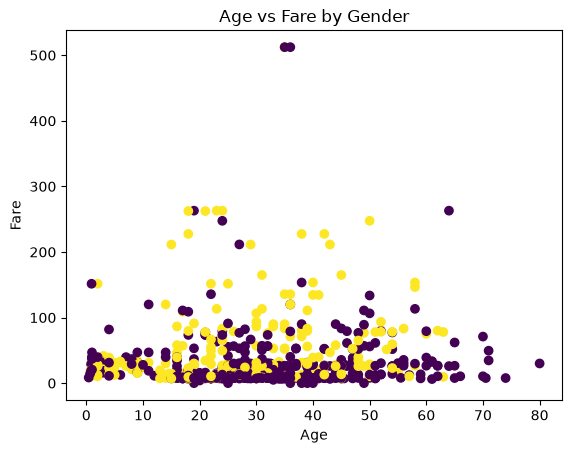

In [6]:
# Creating Scatter Matrix

attributes = ['age', 'fare', 'pclass']
scatter_matrix(titanic[attributes], figsize=(10, 10))
plt.show()

plt.scatter(
    titanic['age'],
    titanic['fare'],
    c=titanic['sex'].apply(
        lambda x: 0 if x == 'male' else 1,
    ),
)
plt.xlabel('Age')
plt.ylabel('Fare')
plt.title('Age vs Fare by Gender')
plt.show()

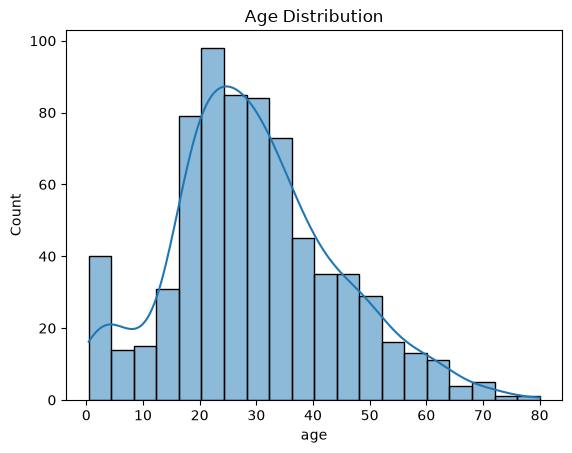

In [7]:
sns.histplot(titanic['age'], kde=True)
plt.title('Age Distribution')
plt.show()

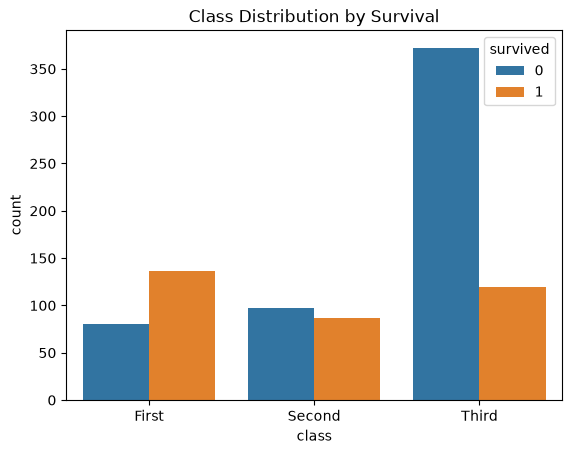

In [8]:
sns.countplot(x='class', hue='survived', data=titanic)
plt.title('Class Distribution by Survival')
plt.show()

## Reflection 2.1 

1) What patterns or anomalies do you notice? - Most passengers were between 20 and 40 years old. 3rd class tickets were the highest number of tickets sold and there were more younger people with 2nd & 3rd class tickets. Most tickets cost under $100. 
2) Do any features stand out as potential predictors? - Which class ticket you bought looks as though it may predict your likelihood of surviving. 
3) Are there any visible class imbalances? - Yes, more first class riders survived than second or third class. 

## 2.2 Handle Missing Values and Clean Data

Age was missing values. 

Embark_town was missing values.



In [9]:
# For age; substitute the median for missing values

titanic['age'] = titanic['age'].fillna(28)
LOG.info("Median age substituted in for missing values")
LOG.info(f'Number of missing values in column:{titanic['age'].isnull().sum()}')

2026-07-16 12:02:23 | INFO | M01 | Median age substituted in for missing values
2026-07-16 12:02:23 | INFO | M01 | Number of missing values in column:0


In [10]:
titanic['embark_town'].mode()

0    Southampton
Name: embark_town, dtype: str

In [11]:
titanic['embark_town'] = titanic['embark_town'].fillna('Southampton')
LOG.info('Missing towns were filled with the most popular, Southampton')
LOG.info(f'Number of missing values in column:{titanic['embark_town'].isnull().sum()}')

2026-07-16 12:02:23 | INFO | M01 | Missing towns were filled with the most popular, Southampton
2026-07-16 12:02:23 | INFO | M01 | Number of missing values in column:0


In [12]:
titanic['embarked'] = titanic['embarked'].fillna('S')
LOG.info('Missing towns were filled with the most popular, S for Southampton')
LOG.info(f'Number of missing values in column:{titanic['embarked'].isnull().sum()}')

2026-07-16 12:02:23 | INFO | M01 | Missing towns were filled with the most popular, S for Southampton
2026-07-16 12:02:23 | INFO | M01 | Number of missing values in column:0


In [13]:
missing: pd.Series = titanic.isna().sum()
LOG.info(f"Missing values by column:\n{missing}")

2026-07-16 12:02:23 | INFO | M01 | Missing values by column:
survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      0
alive            0
alone            0
dtype: int64


## 2.3 Feature Engineering

Create a new feature: Family size

Convert categorical data to numeric

Create a binary feature for 'alone'

In [14]:
# New Feature
titanic['family_size'] = titanic['sibsp'] + titanic['parch'] + 1

In [15]:
# Turn 'sex' & 'embarked' feature into numeric features
titanic['sex'] = titanic['sex'].map({'male': 0, 'female': 1})
titanic['embarked'] = titanic['embarked'].map({'C': 0, 'Q': 1, 'S': 2})

In [16]:
# Turn "alone" feature into a binary feature
titanic['alone'] = titanic['alone'].astype(int)

## Reflection 2

1) Why might family size be a useful feature for predicting survival? - It would help us analyze what about the person made them able to survive, and combining the features into a family simplifies that instead of having to use 3 columns to get the same information. 
2) Why convert categorical data to numeric? - Because if it is numerical it is easier to use formulas on it and therefore it easier to analyze it. 

## Section 3. Feature Selection and Justification

Input Features: age, fare, pclass, sex, family_size

Target: Survived 

In [17]:
# Define x and y

X = titanic[['age', 'fare', 'pclass', 'sex', 'family_size']]
y = titanic['survived']

## Reflection 3

1) Why are these features selected? - These features are selected because they are the main descriptors of a person traveling on the titanic. Your fare and class determined what room you would be in and where your designated sections on the boat would be. Age, sex, and family size would most likely contribute your ability to survive the sinking of the ship. 
2) Are there any features that are likely to be highly predictive of survival? - At this point I would say no, that we have the main factors I would look at. There is a possibility that with more research there could be a reason to include the town where they boarded the Titanic, but right now there is nothing to suggest that. 

## Section 4: Splitting, Training, and Results

Split the data into training and test sets using train_test_split first and StratifiedShuffleSplit second. Compare.

In [18]:
# Basic train/test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=123
)

print('Train size:', len(X_train))
print('Test size:', len(X_test))

print("Original Class Distribution:\n", X['pclass'].value_counts(normalize=True))
print("Train Set Class Distribution:\n", X_train['pclass'].value_counts(normalize=True))
print("Test Set Class Distribution:\n", X_test['pclass'].value_counts(normalize=True))

Train size: 712
Test size: 179
Original Class Distribution:
 pclass
3    0.551066
1    0.242424
2    0.206510
Name: proportion, dtype: float64
Train Set Class Distribution:
 pclass
3    0.557584
1    0.233146
2    0.209270
Name: proportion, dtype: float64
Test Set Class Distribution:
 pclass
3    0.525140
1    0.279330
2    0.195531
Name: proportion, dtype: float64


In [19]:
# Stratified Train/Test Split

splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=123)

for train_indices, test_indices in splitter.split(X, y):
    train_set = X.iloc[train_indices]
    test_set = X.iloc[test_indices]

print('Train size:', len(train_set))
print('Test size:', len(test_set))

Train size: 712
Test size: 179


In [20]:
print("Original Class Distribution:\n", y.value_counts(normalize=True))
print(
    "Train Set Class Distribution:\n", train_set['pclass'].value_counts(normalize=True)
)
print("Test Set Class Distribution:\n", test_set['pclass'].value_counts(normalize=True))

Original Class Distribution:
 survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64
Train Set Class Distribution:
 pclass
3    0.561798
1    0.227528
2    0.210674
Name: proportion, dtype: float64
Test Set Class Distribution:
 pclass
3    0.508380
1    0.301676
2    0.189944
Name: proportion, dtype: float64


In [21]:
print("Original Class Distribution:\n", X['pclass'].value_counts(normalize=True))
print(
    "Train Set Class Distribution:\n", train_set['pclass'].value_counts(normalize=True)
)
print("Test Set Class Distribution:\n", test_set['pclass'].value_counts(normalize=True))

Original Class Distribution:
 pclass
3    0.551066
1    0.242424
2    0.206510
Name: proportion, dtype: float64
Train Set Class Distribution:
 pclass
3    0.561798
1    0.227528
2    0.210674
Name: proportion, dtype: float64
Test Set Class Distribution:
 pclass
3    0.508380
1    0.301676
2    0.189944
Name: proportion, dtype: float64


## Reflection 4

1) Why might stratification improve model performance? - It can improve a model because it can mimic a population more accurately, therefore making the model more accurate. 
2) How close are the training and test distributions to the original dataset? - The training model is very close to the original distribution for the pclass feature, with variation of 0.01 at most for all three classes. The test was slightly less close with a variation of up to 0.08 between the three classes. 
3) Which split method produced better class balance? The basic model produced test results that were closer to the distribution of classes in the original dataset than the stratified test. 

## Index Summarization 

[Index document](./docs/index.md)
